# Single-cell RNA sequencing

This notebook replicates most of the code blocks found in the [Beyond Averages: Understanding Cell-Type Specific Adaptations with Single-Cell RNA Sequencing](https://github.com/evanpeikon/scRNA-seq-guide) post.

In [1]:
import gc

import scanpy as sc
from scipy.sparse import issparse, csr_matrix
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

Load raw data

In [2]:
adata = sc.read_h5ad("../data/raw/training_cells.h5ad")

train_df = pd.read_csv("../data/training_data_means.csv")
output_genes = train_df.columns[1:].tolist()

Check for NaN values

In [3]:
if issparse(adata.X):
    print("Sparse matrix detected, checking for invalid values in non-zero elements...")
    if np.isnan(adata.X.data).any():
        print(f"- number of NaNs in non-zero elements: {np.sum(np.isnan(adata.X.data))}")
    else:
        print("- no NaN values found in non-zero elements.")
else:
    nan_rows = np.isnan(adata.X).any(axis=1)
    nan_cols = np.isnan(adata.X).any(axis=0)
    print(f"- number of rows with NaN values: {np.sum(nan_rows)}")
    print(f"- number of columns with NaN values: {np.sum(nan_cols)}")

Sparse matrix detected, checking for invalid values in non-zero elements...
- no NaN values found in non-zero elements.


In [4]:
adata.obs

,nCount_RNA,nFeature_RNA,percent.mt,sgrna_id,sgrna_symbol,channel
AAACCAAAGACGCGAA_ch_1,16395.0,4191,4.306191,INSIG1_3,INSIG1,ch_1
AAACCAAAGCAAATGA_ch_1,12000.0,3631,3.133333,FLNA_2,FLNA,ch_1
AAACCAAAGCAGTCTA_ch_1,55050.0,7061,5.193460,EIF3H_2,EIF3H,ch_1
AAACCAAAGGGCATAG_ch_1,19586.0,5010,6.494435,DZIP3_4,DZIP3,ch_1
AAACCATTCCAATCGA_ch_1,18744.0,4697,4.604140,non-targeting_25,non-targeting,ch_1
...,...,...,...,...,...,...
GTTGTCCGTCCAGTGA_ch_4,21242.0,4904,4.057998,METTL3_4,METTL3,ch_4
GTTGTCCGTGGGTTTG_ch_4,17462.0,4674,3.928531,non-targeting_25,non-targeting,ch_4
GTTGTCTTCCCCAACC_ch_4,10459.0,3350,6.922268,IKBKG_1,IKBKG,ch_4
GTTGTCTTCCCTTCTC_ch_4,29779.0,5709,3.680446,EGFR_2,EGFR,ch_4


In [5]:
adata.var

,features
A1BG,A1BG
A1CF,A1CF
A2M,A2M
A2ML1,A2ML1
A3GALT2,A3GALT2
...,...
ZYG11A,ZYG11A
ZYG11B,ZYG11B
ZYX,ZYX
ZZEF1,ZZEF1


## Quality control metrics

Calculate comprehensive quality control metrics

In [6]:
target_genes_full = adata.var.features.tolist()

In [7]:
pert_genes_full = adata.obs.sgrna_symbol.unique().tolist()

In [8]:
sc.pp.calculate_qc_metrics(adata, qc_vars=[], percent_top=None, log1p=False, inplace=True)

# identify and calculate mitochondrial content
has_mito = False
for name in adata.obs.columns.tolist():
    if name.startswith("mit") or name.endswith(".mt"):
        mito_name = name
        has_mito = True
        break

# no mito? compute it
if not has_mito:
    mito_name = "pct_counts_mt"
    mt_gene_mask = adata.var_names.str.startswith(("MT-", "mt-"))
    mt_count = np.sum(mt_gene_mask)
    print(f"- found {mt_count} mitochondrial genes")
    if mt_count > 0:
        adata.var["mt"] = mt_gene_mask
        sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)
    else:
        print("- no mitochondrial genes found with standard prefixes")
        adata.obs["pct_counts_mt"] = 0

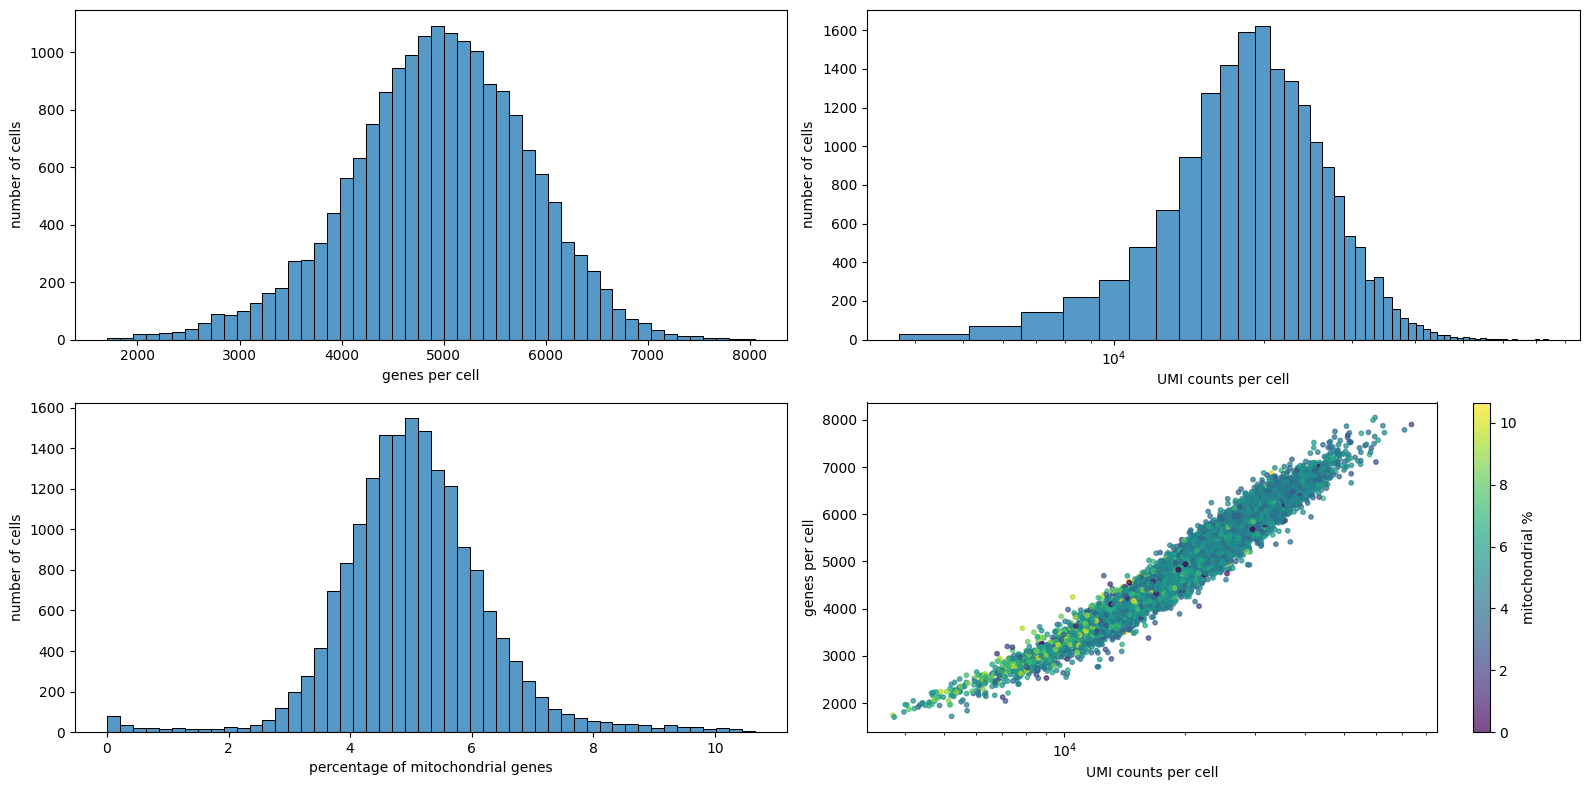

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

# distribution of genes per cell
sns.histplot(adata.obs["n_genes_by_counts"], bins=50, kde=False, ax=axes[0, 0])
axes[0, 0].set_xlabel("genes per cell")
axes[0, 0].set_ylabel("number of cells")

# distribution of UMI counts per cell
sns.histplot(adata.obs["total_counts"], bins=50, kde=False, ax=axes[0, 1])
axes[0, 1].set_xlabel("UMI counts per cell")
axes[0, 1].set_ylabel("number of cells")
axes[0, 1].set_xscale("log")

# distribution of mitochondrial gene percentage
sns.histplot(adata.obs[mito_name], bins=50, kde=False, ax=axes[1, 0])
axes[1, 0].set_xlabel("percentage of mitochondrial genes")
axes[1, 0].set_ylabel("number of cells")

# scatter plot of UMI count vs genes per cell colored by mito percent
scatter = axes[1, 1].scatter(adata.obs["total_counts"], adata.obs["n_genes_by_counts"], c=adata.obs[mito_name], cmap="viridis", s=10, alpha=0.7)
axes[1, 1].set_xlabel("UMI counts per cell")
axes[1, 1].set_ylabel("genes per cell")
axes[1, 1].set_xscale("log")
cbar = plt.colorbar(scatter, ax=axes[1, 1])
cbar.set_label("mitochondrial %")
plt.tight_layout()

## Filter dataset

Based on the previous figure, we choose thresholds to apply to the dataset.

Values used for the HepG2 and Jurkat datasets:

```python
min_genes = 300     # minimum genes per cell
min_cells = 20      # minimum cells per gene
max_mito = 15       # maximum percentage of mitochondrial genes
min_counts = 1000   # minimum UMI counts per cell
max_counts = 100000 # maximum UMI counts
```

In [10]:
min_genes = 300
min_cells = 20
max_mito = 15
min_counts = 1000
max_counts = 100000

Apply filters to dataset

In [11]:
"""
print(f"- before filtering: {adata.n_obs} cells, {adata.n_vars} genes")

# filter cells based on QC metrics
mask = (adata.obs["n_genes_by_counts"] >= min_genes) & (adata.obs[mito_name] <= max_mito)
if min_counts: mask &= (adata.obs["total_counts"] >= min_counts)
if max_counts: mask &= (adata.obs["total_counts"] <= max_counts)

adata = adata[mask]

gc.collect()

# filter genes based on minimum cells
sc.pp.filter_genes(adata, min_cells=min_cells)

print(f"- after filtering: {adata.n_obs} cells, {adata.n_vars} genes")
"""

'\nprint(f"- before filtering: {adata.n_obs} cells, {adata.n_vars} genes")\n\n# filter cells based on QC metrics\nmask = (adata.obs["n_genes_by_counts"] >= min_genes) & (adata.obs[mito_name] <= max_mito)\nif min_counts: mask &= (adata.obs["total_counts"] >= min_counts)\nif max_counts: mask &= (adata.obs["total_counts"] <= max_counts)\n\nadata = adata[mask]\n\ngc.collect()\n\n# filter genes based on minimum cells\nsc.pp.filter_genes(adata, min_cells=min_cells)\n\nprint(f"- after filtering: {adata.n_obs} cells, {adata.n_vars} genes")\n'

Normalize data

In [12]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata, base=2)

## Clusters

Compute and visualize clusters found in the raw dataset

/home/fsbn/.local/share/uv/python/cpython-3.12.11-linux-x86_64-gnu/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/home/fsbn/Workspace/myllia-competition/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


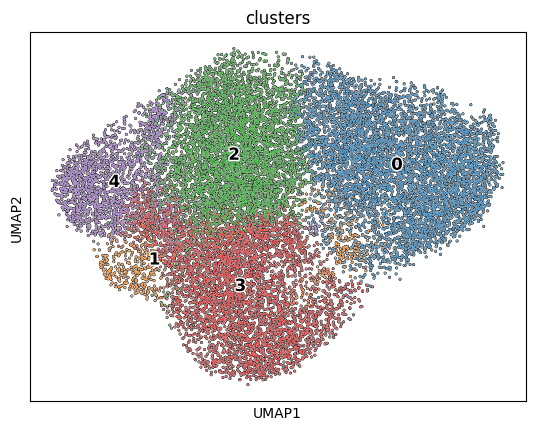

Silhouette Score: 0.06943243741989136


In [13]:
compute_clusters = True
if compute_clusters:
    # apply z-transformation
    sc.pp.scale(adata, zero_center=True)
    # perform dimensionality reduction via PCA
    sc.tl.pca(adata, svd_solver='arpack')
    
    # construct graph of nearest neighbors
    sc.pp.neighbors(adata, n_neighbors=20, n_pcs=30)
    # apply leiden clustering algorithm
    sc.tl.leiden(adata, key_added='clusters', resolution=0.3, n_iterations=3, flavor='igraph', directed=False)
    # create and visualize UMAP
    sc.tl.umap(adata)
    sc.pl.umap(adata, color='clusters', add_outline=True, legend_loc='on data', legend_fontsize=12, legend_fontoutline=2, frameon=True)
    
    labels = adata.obs['clusters']

    from sklearn.metrics import silhouette_score

    sil_score = silhouette_score(adata.obsm['X_pca'], labels)
    print(f'Silhouette Score: {sil_score}')